# Linear Regression

## Y = 2X + 3 最简线性回归 (重要)

实验目的：通过极简数据寻找 $w$ 和 $b$，复盘训练全流程，并建立防遗忘的笔记体系。
关键认知：验证集不改变参数，它改变的是我们的“决策”。

#### 1. 准备数据
 (2D Tensor 是必须的，所以用 .view(-1, 1))

In [1]:
import torch

In [4]:
# y = 2x + 3

X = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)
Y = torch.tensor([[5.0], [7.0], [9.0], [11.0]], dtype=torch.float32)


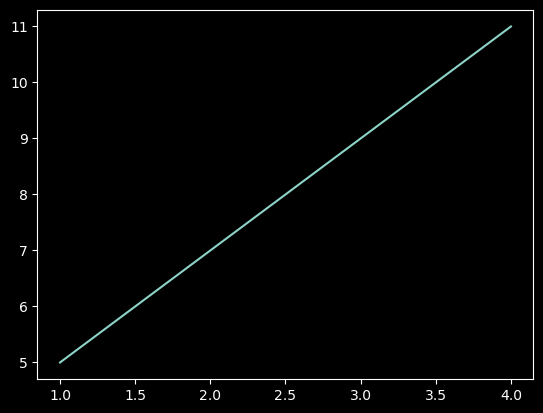

In [5]:
import matplotlib.pyplot as plt

plt.plot(X.numpy(), Y.numpy())
plt.show()

### 2. 定义模型类 (继承 nn.Module)

🏗️ 结构定义我们使用 nn.Linear(1, 1)。
这在内部自动创建了两个变量：
- Weight ($w$): 初始值通常是随机的，目标是收敛到 2.0。
- Bias ($b$): 初始值随机，目标是收敛到 3.0。

注意：在 IBM 的语境中，如果你用训练集来测试这个模型的输出并记录误差，这个数组通常被命名为 test_error，即便它是在训练期间生成的。

In [9]:
from torch import nn


class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        # 创建一个线性回归模型，内容包含w和b
        self.linear = nn.Linear(1, 1) # 输入维度1，输出维度1

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

In [10]:
print(model.state_dict())

OrderedDict([('linear.weight', tensor([[0.8697]])), ('linear.bias', tensor([0.3411]))])


### 3. 定义损失函数和优化器

In [12]:

from torch import optim

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

train_losses = []

### 4. 训练循环 (Training Loop)

🔄 训练五步法 (必须肌肉记忆)
- 梯度清零：optimizer.zero_grad()。如果不清零，PyTorch 会累加之前的梯度。
- 前向传播：y_hat = model(X)。
- 计算损失：loss = criterion(y_hat, Y)。
- 反向传播：loss.backward()。这一步算出梯度。
- 更新参数：optimizer.step()。这一步根据学习率真正修改 $w$ 和 $b$。

In [13]:

for epoch in range(10):
    # --- 核心五步法 ---
    optimizer.zero_grad()        # 1. 清零梯度 (擦黑板)
    y_hat = model(X)             # 2. 前向传播 (算预测值)
    loss = criterion(y_hat, Y)   # 3. 计算损失 (看错多少)
    loss.backward()              # 4. 反向传播 (算导数/梯度)
    optimizer.step()             # 5. 更新参数 (迈出一小步)

    train_losses.append(loss.item()) # 6.保存Loss值
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/500], Loss: {loss.item():.4f}')


### 5. 模型预测

🧪 验证与评估 (Minimize Validation Errors)
为什么我们需要在每个 Epoch 之后（或者训练完成后）进行验证？
- Early Stopping: 如果验证误差不再下降，停止训练。
- Change Hyperparameters: 如果验证误差高，我们需要手动修改学习率 $lr$ 或模型结构。

注意：在 with torch.no_grad(): 块内，模型不会更新任何参数。

In [14]:
# 1. 将模型设为评估模式 (Evaluation Mode)
# 虽然简单的线性回归看不出区别，但在包含 Dropout 或 BatchNorm 的模型中这步至关重要
model.eval()

# 2. 准备测试集 (必须也是 2D Tensor)
X_test = torch.tensor([[5.0], [10.0], [20.0]], dtype=torch.float32)

# 3. 预测 (禁用梯度计算，这是预测时的标准姿势)
with torch.no_grad():
    predictions = model(X_test)

# 4. 查看结果
for i, x in enumerate(X_test):
    print(f"输入 x = {x.item():.1f}, 预测 y_hat = {predictions[i].item():.4f} (理论值: {2*x.item()+3})")

输入 x = 5.0, 预测 y_hat = 12.8196 (理论值: 13.0)
输入 x = 10.0, 预测 y_hat = 24.7174 (理论值: 23.0)
输入 x = 20.0, 预测 y_hat = 48.5131 (理论值: 43.0)


##  2 Stochastic Gradient Descent

In [3]:
w = torch.tensor(-15.0, requires_grad=True)
b = torch.tensor(-10.0, requires_grad=True)

In [4]:
X = torch.arange(-3, 3, 0.1).view(-1, 1)
f = -3 * X

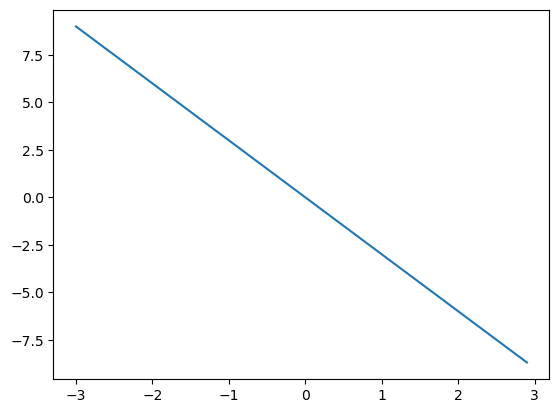

In [5]:
import matplotlib.pyplot as plt

plt.plot(X.numpy(), f.numpy())
plt.show()

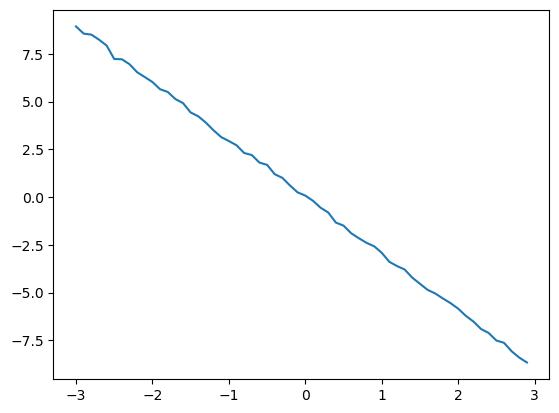

In [6]:
Y = f + 0.1 * torch.randn(X.size())
plt.plot(X.numpy(), Y.numpy())
plt.show()

In [ ]:
def forward(x):
    y = w * x + b
    return y


def criterion(yhat, y):
    return torch.mean((yhat - y) ** 2)

In [ ]:
lr = 0.1
for epoch in range(4):  # 4轮，4次完整遍历
    # 每个iteration计算一个样本的梯度
    for x, y in zip(X, Y):  # 每个数据点一次iteration或batch循环 zip(X,Y)是将X，Y配对
        yhat = forward(x)
        loss = criterion(yhat, y)
        loss.backward()
        w.data -= lr * w.grad.data
        b.data -= lr * b.grad.data
        w.grad.data.zero_()
        b.grad.data.zero_()

### 使用tensorflow实现SGD

In [ ]:
import tensorflow as tf
import numpy as np

# --- 1. 数据准备 (与PyTorch版本一致) ---
# 将 PyTorch 张量转换为 NumPy 或 TensorFlow 张量
X_np = np.arange(-3, 3, 0.1).reshape(-1, 1)  # ~60x1
f_np = -3 * X_np
Y_np = f_np + 0.1 * np.random.randn(*X_np.shape)

# 将 NumPy 数组转换为 TensorFlow 张量
X_tf = tf.constant(X_np, dtype=tf.float32)
Y_tf = tf.constant(Y_np, dtype=tf.float32)

# --- 2. 参数初始化 (手动设置初始值) ---
# 在 Keras 中，我们通常让层自己初始化，但为了匹配原例，可以手动设置
# 注意：TensorFlow/Keras 中，偏置项 b 默认是模型的一部分
initial_w = np.array([[-15.0]], dtype=np.float32)
initial_b = np.array([-10.0], dtype=np.float32)

# --- 3. 学习率 ---
lr = 0.1
## 🛠️ 模型定义
# Keras Sequential 模型用于线性回归
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        units=1,
        input_shape=(1,),  # 输入特征数量是 1
        name='LinearLayer'
    )
])

# 设置初始权重以匹配 PyTorch 示例的 w=-15.0 和 b=-10.0
model.get_layer('LinearLayer').set_weights([initial_w, initial_b])

## ⚙️ 编译模型 (定义优化器和损失函数)
model.compile(
    # 优化器：使用 SGD，并设置学习率
    optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
    # 损失函数：均方误差 (Mean Squared Error)，与 criterion(yhat, y) 对应
    loss='mse'
)

## 🏃 训练模型

# 将数据打包成 tf.data.Dataset 以便逐样本或逐批次训练
# 由于原 PyTorch 代码使用了 SGD (逐样本更新)，我们设置 batch_size=1
train_dataset = tf.data.Dataset.from_tensor_slices((X_tf, Y_tf)).batch(1)
print("开始训练 (Batch Size = 1 对应 SGD/逐样本更新)...")

history = model.fit(
    train_dataset,
    epochs=4,  # 训练轮次，与原代码 for epoch in range(4) 对应
    verbose=0  # 不打印过程，使输出更简洁
)

print("\n训练完成。")

# 打印最终参数
final_w, final_b = model.get_layer('LinearLayer').get_weights()
print(f"最终权重 w: {final_w.flatten()[0]:.4f}")
print(f"最终偏置 b: {final_b[0]:.4f}")

### 使用DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class Data(Dataset):
    def __init__(self):
        self.x = torch.arange(-3, 3, 0.1).view(-1)
        self.y = -3 * self.x  + 1
        self.len = self.x.shape[0]
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    def __len__(self):
        return self.len

dataset = Data()

trainloader = DataLoader(dataset, batch_size=1)
lr = 0.1
for x, y in trainloader:
    yhat = forward(x)
    loss = criterion(yhat, y)
    loss.backward()
    w.data -= lr * w.grad.data
    b.data -= lr * b.grad.data
    w.grad.data.zero_()
    b.grad.data.zero_()


## 3 Mini-Batch Gradient Descent

In [ ]:
from torch.utils.data import Dataset, DataLoader

class Data(Dataset):
    def __init__(self):
        self.x = torch.arange(-3, 3, 0.1).view(-1)
        self.y = -3 * self.x  + 1
        self.len = self.x.shape[0]
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    def __len__(self):
        return self.len

dataset = Data()
# 2个数据一批
trainloader = DataLoader(dataset, batch_size=2)
lr = 0.1
LOSS = []
for x, y in trainloader:
    yhat = forward(x)
    loss = criterion(yhat, y)
    loss.backward()
    w.data -= lr * w.grad.data
    b.data -= lr * b.grad.data
    w.grad.data.zero_()
    b.grad.data.zero_()
    LOSS.append(loss.item())
